# Instalation des dependences

In [ ]:
!pip install pandas

In [2]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.3 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

In [4]:
!pip install scikit-Learn

In [5]:
!pip install sklearn.preprocessing

## 1 - Importation des donnees

In [18]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport

/tmp/ipykernel_1748/1081620318.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [19]:
Edu = pd.read_csv("/content/dataset-6ab002b01f9ef078223946.csv")
Edu.shape
Edu.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


## 2 - Structer general

In [20]:
Edu.describe()


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Data Profiling

In [21]:
ProfileReport(Edu,title="EduPredict Profiling Report")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:00<00:00, 30.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 3 - Les Valeur Manquantes et doublons

In [22]:
Edu.isna().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [23]:
Edu.duplicated().sum()

np.int64(0)

In [24]:
Edu.loc[Edu['Teacher_Quality'].isna()]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
127,17,97,Medium,Medium,No,8,89,Medium,Yes,1,Low,NaN,Public,Neutral,4,No,High School,Far,Male,69
396,10,80,High,Medium,Yes,6,93,High,Yes,4,Medium,NaN,Public,Negative,3,No,College,Moderate,Female,67
457,14,86,Medium,Low,Yes,8,90,Medium,No,3,Medium,NaN,Public,Negative,3,Yes,Postgraduate,Near,Male,65
570,20,71,High,Medium,No,8,77,Medium,Yes,0,High,NaN,Private,Neutral,4,No,High School,Moderate,Male,66
593,22,82,High,Medium,Yes,7,71,Low,Yes,1,High,NaN,Private,Positive,3,No,High School,Near,Female,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6414,22,63,Low,Low,Yes,7,94,Medium,Yes,0,Medium,NaN,Public,Negative,3,Yes,High School,Far,Male,61
6427,29,75,Low,Medium,Yes,7,96,Low,Yes,2,Low,NaN,Public,Positive,3,No,High School,Moderate,Male,68
6461,12,89,Medium,High,Yes,8,78,Low,Yes,4,Low,NaN,Public,Neutral,5,No,Postgraduate,Near,Female,69
6579,9,84,Medium,Medium,No,6,74,Medium,Yes,5,High,NaN,Public,Neutral,2,No,High School,Near,Male,67


## 4 - One-Hot Encoding

In [25]:
Edu_encoding = pd.get_dummies(Edu,columns=['Gender','School_Type','Extracurricular_Activities','Internet_Access','Learning_Disabilities','Peer_Influence'], dtype=int)

## 5 - Distributions (histogrammes sur ExamScore et HoursStudied)

In [26]:
import matplotlib.pyplot as plt

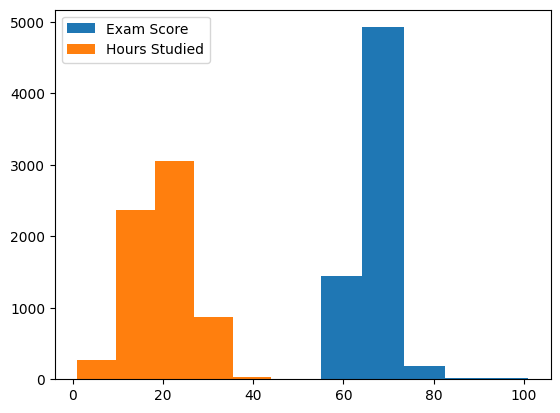

In [27]:
plt.hist(Edu_encoding['Exam_Score'],label="Exam Score",bins=5)
plt.hist(Edu_encoding['Hours_Studied'], label="Hours Studied",bins=5)
plt.legend()
plt.show()

## 6 - Imputation par mode les troi columns et suppressiont les doublons


In [28]:
Edu_encoding['Teacher_Quality'] = Edu_encoding['Teacher_Quality'].fillna(Edu_encoding['Teacher_Quality'].mode()[0])
Edu_encoding['Parental_Education_Level'] = Edu_encoding['Parental_Education_Level'].fillna(Edu_encoding['Parental_Education_Level'].mode()[0])
Edu_encoding['Distance_from_Home'] = Edu_encoding['Distance_from_Home'].fillna(Edu_encoding['Distance_from_Home'].mode()[0])

In [29]:
Edu_encoding.isna().sum().sum()

np.int64(0)

## 7 - les Valeur Aberrantes (Boxplot ,IQR,Z-score)


* **Boxplot**


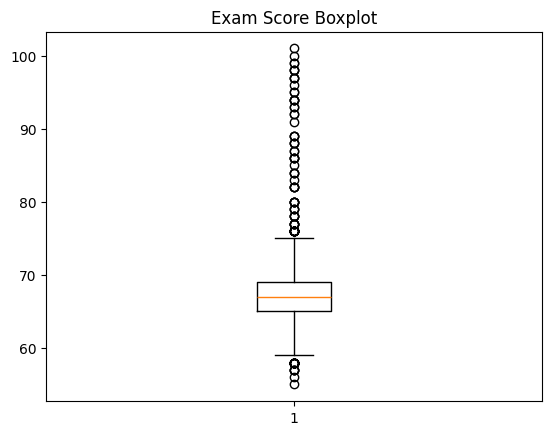

In [30]:
plt.boxplot(Edu_encoding['Exam_Score'])
plt.title("Exam Score Boxplot")
plt.show()



*   **IQR**



In [31]:
Q1 = Edu_encoding['Exam_Score'].quantile(0.25)
Q3 = Edu_encoding['Exam_Score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
supper = Q3 + 1.5 * IQR

Outlier = Edu_encoding[(Edu_encoding['Exam_Score'] < lower) | (Edu_encoding['Exam_Score'] > supper)]

In [32]:
Outlier

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,School_Type_Public,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Learning_Disabilities_No,Learning_Disabilities_Yes,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive
94,18,89,High,Medium,4,73,Medium,3,High,Medium,...,0,0,1,0,1,1,0,0,0,1
106,31,100,Medium,Medium,7,59,Medium,2,High,High,...,1,1,0,0,1,1,0,0,0,1
113,35,99,High,High,7,85,Low,2,Medium,High,...,0,0,1,0,1,1,0,0,1,0
209,43,86,High,Medium,7,97,Medium,2,Medium,High,...,1,0,1,0,1,1,0,0,0,1
217,19,70,Medium,Low,7,54,High,0,Medium,Medium,...,1,1,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6347,28,96,High,Low,4,98,High,1,High,High,...,1,0,1,0,1,1,0,0,0,1
6393,16,83,Low,Medium,8,92,Low,2,High,High,...,1,0,1,0,1,1,0,0,0,1
6431,4,60,Medium,Medium,7,55,Medium,2,Low,Medium,...,0,0,1,0,1,1,0,0,1,0
6522,18,90,High,High,6,54,Low,1,Medium,High,...,1,0,1,0,1,1,0,1,0,0



*   **Z-score**



In [33]:
mean = Edu_encoding['Exam_Score'].mean()
std = Edu_encoding['Exam_Score'].std()
Edu_encoding['Z_Score'] = (Edu_encoding['Exam_Score'] - mean) / std




## Suppresse les Outlier

In [34]:
Edu_encoding.drop(Edu_encoding[Edu_encoding['Exam_Score'] > 100].index,inplace=True)

## 8 - Encodage Ordinal

In [35]:
from numpy import dtype
from sklearn.preprocessing import OrdinalEncoder

cols = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
    ]

ordinal_encoding = OrdinalEncoder(categories=
 [
     Edu_encoding['Parental_Involvement'].unique(),
     Edu_encoding['Access_to_Resources'].unique(),
     Edu_encoding['Motivation_Level'].unique(),
     Edu_encoding['Family_Income'].unique(),
     Edu_encoding['Teacher_Quality'].unique(),
     Edu_encoding['Parental_Education_Level'].unique(),
     Edu_encoding['Distance_from_Home'].unique()
 ])

Edu_encoding[cols] = ordinal_encoding.fit_transform(Edu_encoding[cols])


In [36]:
Edu_encoding

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Learning_Disabilities_No,Learning_Disabilities_Yes,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive,Z_Score
0,23,84,0.0,0.0,7,73,0.0,0,0.0,0.0,...,1,0,0,1,1,0,0,0,1,-0.060574
1,19,64,0.0,1.0,8,59,0.0,2,1.0,0.0,...,1,0,0,1,1,0,1,0,0,-1.602809
2,24,98,1.0,1.0,7,91,1.0,2,1.0,0.0,...,0,1,0,1,1,0,0,1,0,1.738701
3,29,89,0.0,1.0,8,98,1.0,1,1.0,0.0,...,0,1,0,1,1,0,1,0,0,0.967584
4,19,92,1.0,1.0,6,65,1.0,3,1.0,1.0,...,0,1,0,1,1,0,0,1,0,0.710544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,2.0,1.0,7,76,1.0,1,2.0,0.0,...,1,0,0,1,1,0,0,0,1,0.196466
6603,23,76,2.0,1.0,8,81,1.0,3,0.0,1.0,...,1,0,0,1,1,0,0,0,1,0.453505
6604,20,90,1.0,2.0,6,65,0.0,3,0.0,0.0,...,0,1,0,1,1,0,1,0,0,0.196466
6605,10,86,2.0,0.0,6,91,2.0,2,0.0,0.0,...,0,1,0,1,1,0,0,0,1,0.196466


## 9 - Découpage 80% / 20% avec traintestsplit, puis StandardScaler sur les variables numériques.



*   **Découpage** 80% / 20%





In [37]:
from sklearn.model_selection import train_test_split
x = Edu_encoding.drop('Exam_Score',axis=1)
y = Edu_encoding['Exam_Score']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)



*   **StandardScaler**



In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler_data = scaler.fit_transform(x_train)
print(scaler_data)

[[-1.50976073 -0.43310433  1.31906162 ...  1.25851622 -0.8204943
  -0.83164882]
 [-2.01250687 -0.60651671 -0.12279225 ... -0.7945865  -0.8204943
  -1.08653151]
 [-1.67734278 -0.34639813 -0.12279225 ...  1.25851622 -0.8204943
  -1.08653151]
 ...
 [ 0.33364177 -0.25969194 -0.12279225 ... -0.7945865  -0.8204943
  -0.06700077]
 [ 0.16605973 -1.64699103  1.31906162 ...  1.25851622 -0.8204943
  -0.57676614]
 [ 0.16605973 -1.56028484 -0.12279225 ... -0.7945865   1.21877751
  -1.34141419]]


## 10 - Entraîner avec les paramètres par défaut : LinearRegression, RandomForestRegressor, XGBRegressor et SVR, dans un pipeline Scikit-learn.

In [39]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor ,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error , r2_score ,mean_absolute_error
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline

**Training multiple regression models...**

In [40]:
# Define comprehensive set of models
models = {
    "linear Regression" : LinearRegression(),
    # "Ridge Regression" : Ridge(alpha=1.0),
    # "Lasso Regression" : Lasso(alpha=0.1),
    # "Elastic Net" : ElasticNet(alpha=0.1,l1_ratio=0.5),
    "Decision Tree" : DecisionTreeRegressor(random_state=42,max_depth=10),
    "Random Forest" : RandomForestRegressor(n_estimators=100,random_state=42,max_depth=10),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=100,random_state=42),
    "Support Vector Regression" : SVR(kernel="rbf",C=100,gamma=0.1),
    # "K-Nearest Neighbors" : KNeighborsRegressor(n_neighbors=5)
}

## PipeLine

In [41]:
#pipeline
pipelines = {}
for name , model in models.items():
  pipeline = Pipeline([
      ("scaler" , StandardScaler()),
      ("model" , model)
  ])

  pipelines[name] = pipeline

In [42]:
# Train and evaluate models
result = []
model_objects = {}

for name , pipeline in pipelines.items():
  print(f"🔄 Training {name}...")

  # Train model
  pipeline.fit(x_train , y_train)

  # Make predictions
  train_pred = pipeline.predict(x_train)
  test_pred = pipeline.predict(x_test)

  # Calculate metrics
  train_mse = mean_squared_error(y_train,train_pred)
  test_mse = mean_squared_error(y_test,test_pred)
  train_r2 = r2_score(y_train,train_pred)
  test_r2 = r2_score(y_test,test_pred)
  test_mae = mean_absolute_error(y_test,test_pred)

  # Cross-validation score

  cross_val = cross_val_score(model,x_train,y_train, cv=3 ,scoring='r2')
  cv_mean = cross_val.mean()
  cv_std = cross_val.std()

  result.append({
      "Model" : name,
      "Train_MSE" : train_mse,
      "Test_MSE" : test_mse,
      "Train_R2" : train_r2,
      "Test_R2" : test_r2,
      "CV_R2_Mean" : cv_mean,
      "CV_R2_std" : cv_std,
      "Test_MAE" : test_mae,
      "Overfitting" : train_r2 - test_r2
  })

  model_objects[name] = pipeline
# Create comparison DataFrame
comparisan_df = pd.DataFrame(result).sort_values(by="Test_R2",ascending=False)

print(f"\n📊 MODEL COMPARISON RESULTS:")
print("=" * 80)
display_cols = ['Model', 'Test_R2', 'Test_MSE', 'Test_MAE', 'Overfitting']
print(print(comparisan_df[display_cols].round(4).to_string(index=False)))

🔄 Training linear Regression...
🔄 Training Decision Tree...
🔄 Training Random Forest...
🔄 Training Gradient Boosting...
🔄 Training Support Vector Regression...

📊 MODEL COMPARISON RESULTS:
                    Model  Test_R2  Test_MSE  Test_MAE  Overfitting
        linear Regression   1.0000    0.0000    0.0000       0.0000
        Gradient Boosting   0.9999    0.0008    0.0012       0.0001
            Random Forest   0.9998    0.0030    0.0033       0.0002
            Decision Tree   0.9997    0.0045    0.0030       0.0003
Support Vector Regression   0.8531    1.9427    0.6439       0.1463
None


## Grid Searche CV

In [ ]:
# gridSearcheCV
grid_models = {
    "linear Regression" : LinearRegression(),
    # "Ridge Regression" : Ridge(),
    # "Lasso Regression" : Lasso(),
    # "Elastic Net" : ElasticNet(),
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "Random Forest" : RandomForestRegressor(random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(random_state=42),
    "Support Vector Regression" : SVR(),
    # "K-Nearest Neighbors" : KNeighborsRegressor()
}

param_grid = {
    "linear Regression" : {
                            "model__fit_intercept": [True, False],
                            "model__positive": [True, False]
                          },

    # "Ridge Regression" : {
    #                         "model__alpha": [0.01, 0.1, 1, 10, 100],
    #                         "model__fit_intercept": [True, False]
    #                       },

    # "Lasso Regression" : {
    #                         "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    #                         "model__fit_intercept": [True, False],
    #                         "model__max_iter": [1000, 5000, 10000]
    #                      },

    # "Elastic Net" : {
    #                   "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    #                   "model__l1_ratio": [0, 0.25, 0.5, 0.75, 1],
    #                   "model__fit_intercept": [True, False]
    #                 },

    "Decision Tree" :{
                        "model__max_depth": [3, 5, 10, 15, 20, None],
                        "model__min_samples_split": [2, 5, 10],
                        "model__min_samples_leaf": [1, 2, 5, 10],
                        "model__max_features": [None, "sqrt", "log2"]
                      },
    "Random Forest" : {
                          "model__n_estimators": [5,10, 50],
                          "model__max_depth": [5, 10, 20, None],
                          "model__min_samples_split": [2, 5, 10],
                          "model__min_samples_leaf": [1, 2, 5],
                          "model__max_features": [1.0, "sqrt", "log2"]
                        },

    "Gradient Boosting" : {
                              "model__n_estimators": [5, 10, 50],
                              "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
                              "model__max_depth": [2, 3, 5],
                              "model__min_samples_split": [2, 5, 10],
                              "model__min_samples_leaf": [1, 2, 5],
                              "model__subsample": [0.8, 1.0]
                            },
    "Support Vector Regression" : {
                                      "model__kernel": ["linear", "rbf", "poly"],
                                      "model__C": [0.1, 1, 10, 50],
                                      "model__gamma": ["scale", "auto", 0.01, 0.1, 1],
                                      "model__epsilon": [0.01, 0.1, 0.2, 0.5]
                                    },
    # "K-Nearest Neighbors" :  {
    #                             "model__n_neighbors": [3, 5, 7, 9, 11],
    #                             "model__weights": ["uniform", "distance"],
    #                             "model__p": [1, 2]
    #                           }
}

for name , model in models.items():
  grid = GridSearchCV(
      estimator=pipelines[name],
      param_grid = param_grid[name],
      cv=3,
      scoring="r2"
  )
  grid.fit(x_train,y_train)
  print(f"\n🏆 Algo Name : {name}")
  print("Best parameters found: ", grid.best_params_)
  print("Best cross-validation score: ", grid.best_score_)


🏆 Algo Name : linear Regression
Best parameters found:  {'fit_intercept': True, 'positive': True}
Best cross-validation score:  1.0

🏆 Algo Name : Ridge Regression
Best parameters found:  {'alpha': 0.01, 'fit_intercept': True}
Best cross-validation score:  0.9999999999802032


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.142e+03, tolerance: 1.921e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.980e+03, tolerance: 1.922e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.324e+03, tolerance: 1.917e


🏆 Algo Name : Lasso Regression
Best parameters found:  {'alpha': 0.001, 'fit_intercept': True, 'max_iter': 1000}
Best cross-validation score:  0.9999998424432619


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.189e+01, tolerance: 6.633e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.190e+01, tolerance: 6.715e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode


🏆 Algo Name : Elastic Net
Best parameters found:  {'alpha': 0.001, 'fit_intercept': True, 'l1_ratio': 1}
Best cross-validation score:  0.9999998424432619

🏆 Algo Name : Decision Tree
Best parameters found:  {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best cross-validation score:  0.9994354219682997

🏆 Algo Name : Random Forest
Best parameters found:  {'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score:  0.9996665122175127

🏆 Algo Name : Gradient Boosting
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.8}
Best cross-validation score:  0.9999064699679957


In [ ]:
# Select best model
best_model_entry = comparisan_df.iloc[0]
best_model = model_objects[best_model_entry['Model']]
best_model_name = best_model_entry['Model']

print(f"\n🏆 BEST MODEL SELECTED: {best_model_name}")
print(f"   • Test R² Score: {best_model_entry['Test_R2']:.4f}")
print(f"   • Test MSE: {best_model_entry['Test_MSE']:.4f}")
print(f"   • Cross-validation R²: {best_model_entry['CV_R2_Mean']:.4f} (±{best_model_entry['CV_R2_Std']:.4f})")


🏆 BEST MODEL SELECTED: linear Regression
   • Test R² Score: 1.0000
   • Test MSE: 0.0000


## Save Model (PipeLine)

In [ ]:
import joblib

joblib.dump(best_model,"best_model.pkl")


## Download Fille

In [ ]:
import google.colab import files

files.download("best_model.pkl")

## StrimLit UA

In [ ]:
import strimlit as st

# ['Hours_Studied', 'Attendance', 'Parental_Involvement',
#        'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
#        'Previous_Scores', 'Motivation_Level', 'Internet_Access',
#        'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
#        'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
#        'Parental_Education_Level', 'Distance_from_Home', 'Gender',
#        'Exam_Score']

st.title("Student Exam score Predictor")

Hours_Studied = st.slide("Hours Studied")
Attendance = st.slide('Attendance')
Parental_Involvement = st.slide('Parental Involvement')
Access_to_Resources = st.slide('Access to Resources')
Motivation_Level = st.slide('Motivation Level')
Internet_Access = st.slide('Internet Access')
Tutoring_Sessions = st.slide('Tutoring Sessions')
Family_Income = st.slide('Family Income')
Teacher_Quality = st.slide('Teacher Quality')
School_Type = st.slide('School Type')
Peer_Influence = st.slide('Peer Influence')
Physical_Activity = st.slide('Physical Activity')
Learning_Disabilities = st.slide('Learning Disabilities')
Parental_Education_Level = st.slide('Parental Education Level')
Distance_from_Home = st.slide('Distance from Home')
Gender = st.selectbox('Gender',['Homme','Famme'])



*   **LinearRegression**

In [ ]:
# from sklearn.linear_model import LinearRegression

# linear = LinearRegression()
# linear.fit(x_train,y_train)
# print(linear.score(x_test,y_test))

# y_pred = linear.predict(x_test)

1.0


In [ ]:
# x_test.shape
y_test.shape

(1322,)

In [ ]:
x_test.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Sleep_Hours', 'Previous_Scores',
       'Motivation_Level', 'Tutoring_Sessions', 'Family_Income',
       'Teacher_Quality', 'Physical_Activity', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender_Female', 'Gender_Male',
       'School_Type_Private', 'School_Type_Public',
       'Extracurricular_Activities_No', 'Extracurricular_Activities_Yes',
       'Internet_Access_No', 'Internet_Access_Yes', 'Learning_Disabilities_No',
       'Learning_Disabilities_Yes', 'Peer_Influence_Negative',
       'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Z_Score'],
      dtype='object')

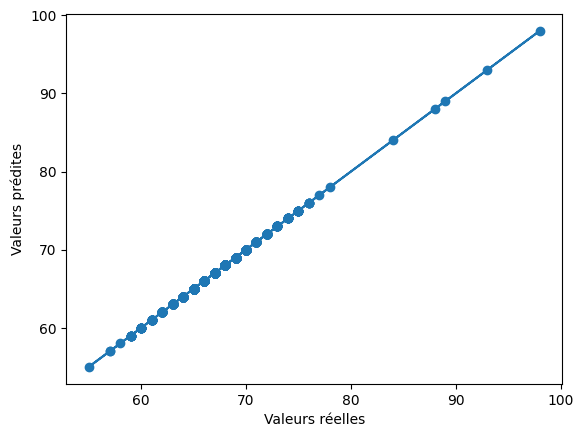

In [ ]:
plt.scatter(y_test,y_test )
plt.plot(y_test,y_pred)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.show()



*   **RandomForestRegressor**



In [ ]:
Edu_encoding['Exam_Score']

,Exam_Score
0,67
1,61
2,74
3,71
4,70
...,...
6602,68
6603,69
6604,68
6605,68
